<img src="https://geo-credito-rural.github.io/_static/logo.jpeg" align="right" width="64" />

# <span style="color:#336699">Impedimentos Sociais, Ambientais e Climáticos</span>

<hr style="border:2px solid #0077b9;">
<div style="text-align: left;">
    <a href="https://nbviewer.jupyter.org/github/brazil-data-cube/code-gallery/blob/master/jupyter/Python/stac/stac-image-processing.ipynb"><img src="https://raw.githubusercontent.com/jupyter/design/master/logos/Badges/nbviewer_badge.svg" align="center"/></a>
</div>

<br/>

<div style="text-align: center;font-size: 90%;">
     Gabriel Sansigolo, Thales Sehn Körting, Gilberto Queiroz, Karine Ferreira, Marcos Adami
    <br/><br/>
    Divisão de Observação da Terra e Geoinformática, Instituto Nacional de Pesquisas Espaciais (INPE)
    <br/>
    Avenida dos Astronautas, 1758, Jardim da Granja, São José dos Campos, SP 12227-010, Brazil
    <br/><br/>
    Contato: <a href="https://geo-credito-rural.github.io/">Equipe - Geo Credito Rural</a>
    <br/><br/>
    Última atualização: 11 de abril de 2026
</div>


<br/>

</div>

Esse notebook aborda de forma simplificada as restrições legais para o acesso ao crédito rural com base em critérios sociais, ambientais e climáticos.

# <span style="color:#336699">Contextualização</span>
<hr style="border:1px solid #0077b9;">

Com as recentes atualizações do Conselho Monetário Nacional (como as Resoluções CMN Nº 5.193/2024, 5.267/2025 e 5.268/2025), a verificação de financiamentos tornou-se mais rigorosa. Hoje, exige-se a identificação da propriedade via Cadastro Ambiental Rural (CAR) e o monitoramento obrigatório por sensoriamento remoto para áreas superiores a 300 hectares, garantindo que os recursos financiados respeitem a conformidade socioambiental.

Na atividade prática de hoje, vamos analisar os impedimentos definidos para esses empreendimentos.

# <span style="color:#336699">6 - Assentamentos, Comunidades Trad. ou Áreas de Uso Coletivo</span>
<hr style="border:1px solid #0077b9;">

De acordo com o Instituto Nacional de Colonização e Reforma Agrária (Incra) o assentamento de reforma agrária é composto por um conjunto de unidades (ou lotes) agrícolas em que cada unidade é destinada a uma família de agricultor ou trabalhador rural sem condições econômicas de adquirir um imóvel rural. Os assentamentos podem ser divididos em dois grupos: a) os criados por meio de obtenção de terras pelo Incra, na forma tradicional, denominados Projetos de Assentamento (PA), que incluem os ambientalmente diferenciados e o Projeto Descentralizado de Assentamento Sustentável (PDAS); b) os implantados por instituições governamentais e reconhecidos pelo Incra para acesso a algumas políticas públicas do Programa Nacional de Reforma Agrária (PNRA). A Tabela 4.9 apresenta as modalidades de assentamentos criadas pelo Incra.

De acordo com a Resolução CMN Nº 5.193/2024:

> 10 - Não será concedido crédito rural para empreendimento localizado em imóvel rural em que exista embargo de
órgão ambiental competente, federal ou estadual, conforme as competências de que tratam os arts. 7º e 8º da Lei
Complementar nº 140, de 8 de dezembro de 2011, decorrente de uso econômico de áreas desmatadas ilegalmente
no imóvel rural e desde que registrado na lista de embargos do Cadastro de Autuações Ambientais e Embargos
do Instituto Brasileiro do Meio Ambiente e dos Recursos Naturais Renováveis (Ibama). (Res CMN 5.193 art 1º)

> 11 - A vedação de que trata o item 10 não se aplica aos financiamentos de investimento com a finalidade exclusiva
de recuperação da vegetação nativa da área embargada do imóvel rural, devendo o mutuário apresentar os
seguintes documentos além daqueles exigidos para a concessão do crédito, que deverão integrar o dossiê da
operação: (Res CMN 5.193 art 1º)
a) projeto técnico elaborado em conformidade com a regulamentação aplicável e protocolado no órgão ambiental
autuante para a implementação da recuperação da área embargada por desmatamento ilegal; e
b) comprovante de pagamento de multas das infrações referentes aos embargos do respectivo imóvel vigentes no
momento da contratação.

> 13 - Nos imóveis rurais ocupados por assentamentos da reforma agrária, por povos e comunidades tradicionais e nos
Projetos Públicos de Irrigação de que trata a Lei nº 12.787, de 11 de janeiro de 2013, exclusivamente nos casos
em que o CAR for referente ao perímetro do imóvel de uso coletivo, o impedimento de que trata o item 10 não
terá alcance sobre a área integral do imóvel rural, sendo aplicado somente para a área embargada e para
financiamento rural cujo proponente seja o responsável pelo embargo, conforme conste no Cadastro de
Autuações Ambientais e Embargos do Ibama. (Res CMN 5.193 art 1º


Uma representação ilustrativa em forma de diagrama da restrição pode ser observada na Figura 6:

![car](https://i.imgur.com/JkjjcQx.png "Assentamentos, Comunidades Trad. ou Áreas de Uso Coletivo")

Prática: vamos simular a verificação de sobreposição.




**Configuração e Exemplo que NÂO atende a norma**

In [ ]:
empreendimento = {
    "geometria": Polygon([(0, 0), (1, 0), (1, 1), (0, 1)]),
    "proponente": "Marcos Souza",
    "area_embargada": Polygon([(0.1, 0.1), (0.4, 0.1), (0.4, 0.4), (0.1, 0.4)])
}

In [ ]:
lista_assentamentos = [
    {
        "nome": "Assentamento Primavera",
        "geometria": Polygon([(0.5, 0.5), (2, 0.5), (2, 2), (0.5, 2)]),
        "existe_embargo_ambiental": True,
        "responsavel_infracao": "Carlos Silva"
    },
    {
        "nome": "Assentamento Boa Esperança",
        "geometria": Polygon([(5, 5), (6, 5), (6, 6), (5, 6)]),
        "existe_embargo_ambiental": False,
        "responsavel_infracao": "Nenhum"
    },
    {
        "nome": "Assentamento Terra Livre",
        "geometria": Polygon([(0, 0), (0.5, 0), (0.5, 0.5), (0, 0.5)]),
        "existe_embargo_ambiental": True,
        "responsavel_infracao": "Marcos Souza"
    },
    {
        "nome": "Assentamento Novo Rumo",
        "geometria": Polygon([(10, 10), (11, 10), (11, 11), (10, 11)]),
        "existe_embargo_ambiental": False,
        "responsavel_infracao": "Nenhum"
    },
]

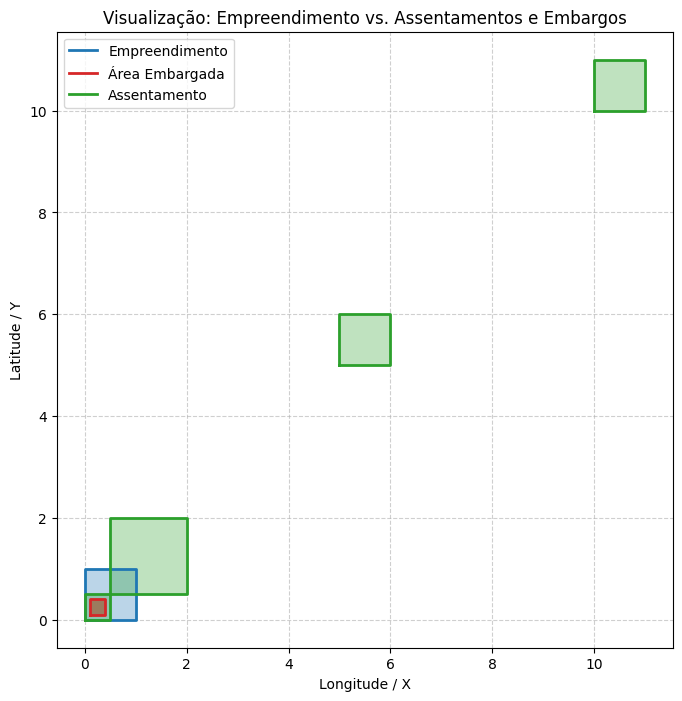

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

x_emp, y_emp = empreendimento["geometria"].exterior.xy
ax.plot(x_emp, y_emp, color='#1f77b4', linewidth=2, label='Empreendimento')
ax.fill(x_emp, y_emp, color='#1f77b4', alpha=0.3)

x_emb, y_emb = empreendimento["area_embargada"].exterior.xy
ax.plot(x_emb, y_emb, color='#d62728', linewidth=2, label='Área Embargada')
ax.fill(x_emb, y_emb, color='#d62728', alpha=0.6)

for i, assentamento in enumerate(lista_assentamentos):
    x_assent, y_assent = assentamento["geometria"].exterior.xy
    label = 'Assentamento' if i == 0 else None
    ax.plot(x_assent, y_assent, color='#2ca02c', linewidth=2, label=label)
    ax.fill(x_assent, y_assent, color='#2ca02c', alpha=0.3)

ax.set_aspect('equal')
ax.set_title('Visualização: Empreendimento vs. Assentamentos e Embargos')
ax.set_xlabel('Longitude / X')
ax.set_ylabel('Latitude / Y')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
imovel_atende_norma = True
motivo_impedimento = ""

for i, assentamento in enumerate(lista_assentamentos):

    # Verifica se a geometria do empreendimento possui sobreposição com o assentamento atual.
    if empreendimento["geometria"].intersects(assentamento["geometria"]):

        # Verifica se existe algum registro de embargo ambiental para este assentamento.
        if assentamento["existe_embargo_ambiental"]:

            # Verifica se a parte específica do embargo ambiental atinge a área do empreendimento.
            if empreendimento["geometria"].intersects(empreendimento["area_embargada"]):

                # Verifica se o nome do proponente é o mesmo nome listado como responsável pelo embargo.
                if empreendimento["proponente"] == assentamento["responsavel_infracao"]:
                    imovel_atende_norma = False
                    motivo_impedimento = f"proponente é o infrator na área embargada do {assentamento['nome']}."
                    break
                else:
                    pass
            else:
                pass
        else:
            pass
    else:
        pass

# Verifica se o imóvel passou por todas as camadas de filtragem da lista.
if imovel_atende_norma:
    print("O empreendimento atende a norma.")
# Caso tenha ocorrido um bloqueio por responsabilidade direta sobre infração em área embargada.
else:
    print(f"O empreendimento não atende a norma porque: {motivo_impedimento}")

O empreendimento não atende a norma porque: proponente é o infrator na área embargada do Assentamento Primavera.


**Configuração e Exemplo atende a norma**

In [ ]:
empreendimento = {
    "geometria": Polygon([(0, 0), (1, 0), (1, 1), (0, 1)]),
    "proponente": "Marcos Souza",
    "area_embargada": Polygon([(0.1, 0.1), (0.4, 0.1), (0.4, 0.4), (0.1, 0.4)])
}

In [ ]:
lista_assentamentos = [
    {
        "nome": "Assentamento Primavera",
        "geometria": Polygon([(0.5, 0.5), (2, 0.5), (2, 2), (0.5, 2)]),
        "existe_embargo_ambiental": True,
        "responsavel_infracao": "Carlos Silva"
    },
    {
        "nome": "Assentamento Boa Esperança",
        "geometria": Polygon([(5, 5), (6, 5), (6, 6), (5, 6)]),
        "existe_embargo_ambiental": False,
        "responsavel_infracao": "Nenhum"
    },
    {
        "nome": "Assentamento Novo Rumo",
        "geometria": Polygon([(10, 10), (11, 10), (11, 11), (10, 11)]),
        "existe_embargo_ambiental": False,
        "responsavel_infracao": "Nenhum"
    },
]

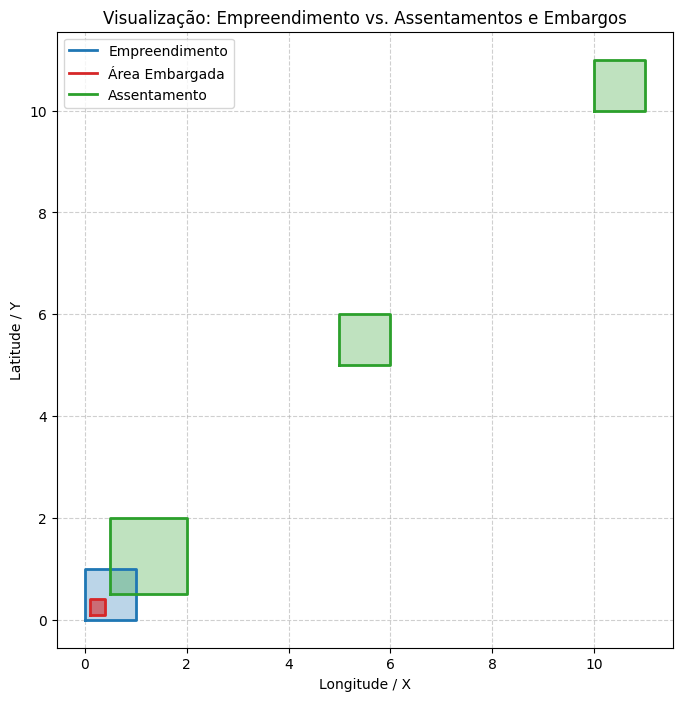

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

x_emp, y_emp = empreendimento["geometria"].exterior.xy
ax.plot(x_emp, y_emp, color='#1f77b4', linewidth=2, label='Empreendimento')
ax.fill(x_emp, y_emp, color='#1f77b4', alpha=0.3)

x_emb, y_emb = empreendimento["area_embargada"].exterior.xy
ax.plot(x_emb, y_emb, color='#d62728', linewidth=2, label='Área Embargada')
ax.fill(x_emb, y_emb, color='#d62728', alpha=0.6)

for i, assentamento in enumerate(lista_assentamentos):
    x_assent, y_assent = assentamento["geometria"].exterior.xy
    label = 'Assentamento' if i == 0 else None
    ax.plot(x_assent, y_assent, color='#2ca02c', linewidth=2, label=label)
    ax.fill(x_assent, y_assent, color='#2ca02c', alpha=0.3)

ax.set_aspect('equal')
ax.set_title('Visualização: Empreendimento vs. Assentamentos e Embargos')
ax.set_xlabel('Longitude / X')
ax.set_ylabel('Latitude / Y')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
imovel_atende_norma = True
motivo_impedimento = ""

for i, assentamento in enumerate(lista_assentamentos):

    # Verifica se a geometria do empreendimento possui sobreposição com o assentamento atual.
    if empreendimento["geometria"].intersects(assentamento["geometria"]):

        # Verifica se existe algum registro de embargo ambiental para este assentamento.
        if assentamento["existe_embargo_ambiental"]:

            # Verifica se a parte específica do embargo ambiental atinge a área do empreendimento.
            if empreendimento["geometria"].intersects(empreendimento["area_embargada"]):

                # Verifica se o nome do proponente é exatamente o mesmo do responsável pelo embargo.
                if empreendimento["proponente"] == assentamento["responsavel_infracao"]:
                    imovel_atende_norma = False
                    motivo_impedimento = f"proponente é o infrator na área embargada do {assentamento['nome']}."
                    break
                else:
                    # O proponente não é o responsável, então pode continuar.
                    pass
            else:
                pass
        else:
            pass
    else:
        pass

# Verifica se o imóvel passou por todas as camadas de filtragem da lista.
if imovel_atende_norma:
    print("O empreendimento atende a norma.")
# Caso tenha ocorrido um bloqueio por responsabilidade direta sobre infração.
else:
    print(f"O empreendimento não atende a norma porque: {motivo_impedimento}")

O empreendimento atende a norma.
